# 311 Service Requests from Louisville, KY in 2025
### Exploratory Data Analysis

Import libraries and data, then get the shape and scope of the data.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

lou311 = pd.read_csv('metro_311_2025.csv')
print(lou311.info())

/tmp/ipykernel_20707/1097768212.py:5: DtypeWarning: Columns (0: source, 1: description, 2: zip_code, 3: council_district) have mixed types. Specify dtype option on import or set low_memory=False.
  lou311 = pd.read_csv('metro_311_2025.csv')


<class 'pandas.DataFrame'>
RangeIndex: 182490 entries, 0 to 182489
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   service_request_id  182490 non-null  str    
 1   requested_datetime  182490 non-null  str    
 2   probyear            182490 non-null  int64  
 3   updated_datetime    136948 non-null  str    
 4   closed_date         122547 non-null  str    
 5   status_description  182490 non-null  str    
 6   status_notes        0 non-null       float64
 7   source              106785 non-null  str    
 8   service_name        182490 non-null  str    
 9   description         115872 non-null  str    
 10  agency_responsible  20296 non-null   str    
 11  address             129116 non-null  str    
 12  longitude           182490 non-null  float64
 13  latitude            182490 non-null  float64
 14  zip_code            127137 non-null  object 
 15  council_district    132913 non-null  object 


Python provides the warning:

    DtypeWarning: Columns (0: source, 1: description, 2: zip_code, 3: council_district) have mixed types.

Date columns are also stored as strings.

Re-read the CSV, converting mixed type columns to strings, and parse date columns as dates.

In [14]:
# create a dictionary to help assign new data types to mixed type columns
dtype_fix = {'source': 'str', 'description': 'str', 'zip_code': 'str', 'council_district': 'str'}
# re-read the CSV using the new data type assignments and interpret the dates as dates
lou311 = pd.read_csv('metro_311_2025.csv', dtype=dtype_fix, parse_dates=['requested_datetime', 'updated_datetime', 'closed_date'])

print(lou311.info())

print('= = = = = = = = = = = = = = = = = = = =')

print('# of unique values per column:')
print(lou311.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 182490 entries, 0 to 182489
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   service_request_id  182490 non-null  str           
 1   requested_datetime  182490 non-null  datetime64[us]
 2   probyear            182490 non-null  int64         
 3   updated_datetime    136948 non-null  datetime64[us]
 4   closed_date         122547 non-null  datetime64[us]
 5   status_description  182490 non-null  str           
 6   status_notes        0 non-null       float64       
 7   source              106785 non-null  str           
 8   service_name        182490 non-null  str           
 9   description         115872 non-null  str           
 10  agency_responsible  20296 non-null   str           
 11  address             129116 non-null  str           
 12  longitude           182490 non-null  float64       
 13  latitude            182490 non-null  flo

### Data Cleaning

Which columns have missing data?

In [3]:
print(lou311.isnull().sum())

service_request_id         0
requested_datetime         0
probyear                   0
updated_datetime       45542
closed_date            59943
status_description         0
status_notes          182490
source                 75705
service_name               0
description            66618
agency_responsible    162194
address                53374
longitude                  0
latitude                   0
zip_code               55353
council_district       49577
ObjectId                   0
x                          0
y                          0
dtype: int64


Because the number of null values in *status_notes* is equal to the total number of rows, *status_notes* is an unused column to be dropped.

The last three columns, *ObjectId*, *x*, and *y* all have entries in every row, but the source webpage at data.louisvilleky.gov makes no mention of these columns in the detailed dataset description. 


A glance at *ObjectId* reveals it to be a simple counter, and so functionally indistinguishable from the baseline index values.


In [16]:
print(lou311['ObjectId'].head(10))

0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
Name: ObjectId, dtype: int64


From the *.nunique* output ("# of unique values" table above), *x* has the same number of entries as *longitude*, and *y* has the same number of entries as *latitude*.

Are they, in fact, the same?

In [17]:
# sort both x and longitude then compare
x_asc = lou311['x'].sort_values()
long_asc = lou311['longitude'].sort_values()
print('Column x = column longitude: ', x_asc.equals(long_asc))
# sort both y and latitude then compare
y_asc = lou311['y'].sort_values()
lat_asc = lou311['latitude'].sort_values()
print('Column y = column latitude: ', y_asc.equals(lat_asc))

Column x = column longitude:  False
Column y = column latitude:  False


*x* and *y* are apparently **not** *longitude* and *latitude*. 

That the number of unique values matching between this pair of pairs is likely more than coincidental. But since they cannot be reliably identified and are not described by the source, they are dropped from the cleaned data set. The original data set is retained in case it is needed later.

Ultimately, the columns *status_notes*, *ObjectId*, *x*, and *y* are dropped.

In [19]:
lou311_clean = lou311.drop(labels = ['status_notes', 'ObjectId', 'x', 'y'], axis='columns')
lou311_clean.columns

Index(['service_request_id', 'requested_datetime', 'probyear',
       'updated_datetime', 'closed_date', 'status_description', 'source',
       'service_name', 'description', 'agency_responsible', 'address',
       'longitude', 'latitude', 'zip_code', 'council_district'],
      dtype='str')

In [10]:
print(lou311_clean.info())

<class 'pandas.DataFrame'>
RangeIndex: 182490 entries, 0 to 182489
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   service_request_id  182490 non-null  str           
 1   requested_datetime  182490 non-null  datetime64[us]
 2   probyear            182490 non-null  int64         
 3   updated_datetime    136948 non-null  datetime64[us]
 4   closed_date         122547 non-null  datetime64[us]
 5   status_description  182490 non-null  str           
 6   source              106785 non-null  str           
 7   service_name        182490 non-null  str           
 8   description         115872 non-null  str           
 9   agency_responsible  20296 non-null   str           
 10  address             129116 non-null  str           
 11  longitude           182490 non-null  float64       
 12  latitude            182490 non-null  float64       
 13  zip_code            127137 non-null  str

Are there any truly duplicate rows?

In [11]:
lou311_clean.duplicated().sum()

np.int64(0)

No duplicate rows.

## Questions About ZIP Codes
* How many ZIP codes are represented?
* Which ZIP codes most frequently utilize 311 services?
* Do the types of service requests vary by ZIP code? If so, are there identifiable patterns to what types of requests are made from where?

**Further investigation on ZIP codes**
* Many entries are missing zip_code, but no entires are missing latitude or longitude. 
* Why are so many entries missing *zip_code*? 
* How many entries are missing *zip_code*?
* If needed, can *zip_code* be derived from a combination of *latitude* and *longitude*? 
* If needed, could the same process to backfill *zip_code* be used for *council_district*?

In [26]:
# count entries missing zip_code
missing_zips = lou311_clean['zip_code'].isnull().sum()
pct_missing_zips = lou311_clean['zip_code'].isnull().sum() / lou311_clean['service_request_id'].value_counts().sum() * 100

print('# of entries missing ZIP codes: ',  "{:,}".format(missing_zips))
print('% of entries missing ZIP codes: ', "{:.2f}".format(pct_missing_zips), "%")

print('- - -')

print('ZIP codes column info:')
print(lou311['zip_code'].describe())


# of entries missing ZIP codes:  55,353
% of entries missing ZIP codes:  30.33 %
- - -
ZIP codes column info:
count     127137
unique        43
top        40211
freq        9612
Name: zip_code, dtype: object


In [20]:
lou311_clean[lou311_clean['zip_code'].isnull()].nunique()

service_request_id    55353
requested_datetime      353
probyear                  1
updated_datetime        366
closed_date             354
status_description        2
source                    1
service_name             50
description           13482
agency_responsible       26
address                1764
longitude               829
latitude                826
zip_code                  0
council_district         27
dtype: int64

Nearly ***one third*** of all service requests in 2025 are missing an entry in the ZIP code column. 

In [37]:
lou311_clean[lou311_clean['zip_code'].isnull()]

,service_request_id,requested_datetime,probyear,updated_datetime,closed_date,status_description,source,service_name,description,agency_responsible,address,longitude,latitude,zip_code,council_district
1,SR-MISC-25-000351,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Miscellaneous,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN
2,SR-MTRO-25-000250,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Metro Agencies,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN
3,SR-MTRO-25-000352,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Metro Agencies,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN
5,SR-UTIL-25-000251,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Utility,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN
6,SR-MTRO-25-000252,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Metro Agencies,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181968,SR-BAPT-25-112124,2025-07-25 04:00:00,2025,2025-07-25 04:00:00,2025-07-25 04:00:00,CLOSED,NaN,Large Item Appointment,NaN,NaN,140-199 N CRESTMOOR AVE,-85.740657,38.283469,NaN,9
182025,SR-MSDS-25-151335,2025-10-10 04:00:00,2025,2025-10-10 04:00:00,NaT,OPEN,NaN,Solid Waste Missed Services,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN
182044,SR-SIGN-25-119037,2025-08-07 04:00:00,2025,2025-08-12 04:00:00,2025-08-12 04:00:00,CLOSED,NaN,Street Signs,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN
182091,SR-BAPT-25-091213,2025-06-17 04:00:00,2025,2025-06-17 04:00:00,2025-06-17 04:00:00,CLOSED,NaN,Large Item Appointment,NaN,NaN,NaN,-85.740657,38.283469,NaN,3


In [27]:
lou311_clean['zip_code'].unique()

<StringArray>
[     '40217',          nan,      '40210',      '40206',      '40204',
      '40219',      '40216',      '40205',      '40214',      '40212',
      '40207',      '40215',      '40258',      '40228',      '40211',
      '40299',      '40203',      '40213',      '40229',      '40218',
      '40023',      '40220',      '40222',      '40208',      '40291',
      '40272',      '40241',      '40245',      '40223',      '40059',
      '40177',      '40242',      '40118',      '40202',      '40243',
      '40209',      '40225',      '40025', '40219-0000',      '40041',
      '47130', '40207-0000', '40208-0000',      '40165']
Length: 44, dtype: str

We also have some accidental duplicate ZIP codes, i.e. '40207' and '40207-0000', so we will need to deal with those as well.
The most reasonable option is to simply replace the three ZIPs with a '-0000' suffix with their 5-digit base.
And since the ZIP variable is a string, we can replace NaN with "Unknown".

In [16]:
# Consolidate the '-0000' ZIPs into their "correct" counterparts.
lou311_clean.replace({'zip_code': {'40207-0000': '40207', '40208-0000': '40208', '40219-0000': '40219'}}, inplace=True)
lou311_clean['zip_code'].unique()


<StringArray>
['40217',     nan, '40210', '40206', '40204', '40219', '40216', '40205',
 '40214', '40212', '40207', '40215', '40258', '40228', '40211', '40299',
 '40203', '40213', '40229', '40218', '40023', '40220', '40222', '40208',
 '40291', '40272', '40241', '40245', '40223', '40059', '40177', '40242',
 '40118', '40202', '40243', '40209', '40225', '40025', '40041', '47130',
 '40165']
Length: 41, dtype: str

In [17]:
# Ditch the null ZIP codes for 'Unknown'
lou311_clean.fillna({'zip_code': 'Unknown'}, inplace=True)
lou311_clean[lou311_clean['zip_code'].isnull()]
lou311_clean[lou311_clean['zip_code'] == 'Unknown']

,service_request_id,requested_datetime,probyear,updated_datetime,closed_date,status_description,source,service_name,description,agency_responsible,address,longitude,latitude,zip_code,council_district
1,SR-MISC-25-000351,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Miscellaneous,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
2,SR-MTRO-25-000250,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Metro Agencies,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
3,SR-MTRO-25-000352,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Metro Agencies,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
5,SR-UTIL-25-000251,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Utility,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
6,SR-MTRO-25-000252,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Metro Agencies,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181968,SR-BAPT-25-112124,2025-07-25 04:00:00,2025,2025-07-25 04:00:00,2025-07-25 04:00:00,CLOSED,NaN,Large Item Appointment,NaN,NaN,140-199 N CRESTMOOR AVE,-85.740657,38.283469,Unknown,9
182025,SR-MSDS-25-151335,2025-10-10 04:00:00,2025,2025-10-10 04:00:00,NaT,OPEN,NaN,Solid Waste Missed Services,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
182044,SR-SIGN-25-119037,2025-08-07 04:00:00,2025,2025-08-12 04:00:00,2025-08-12 04:00:00,CLOSED,NaN,Street Signs,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
182091,SR-BAPT-25-091213,2025-06-17 04:00:00,2025,2025-06-17 04:00:00,2025-06-17 04:00:00,CLOSED,NaN,Large Item Appointment,NaN,NaN,NaN,-85.740657,38.283469,Unknown,3


### Visualizing number of service requests by ZIP code

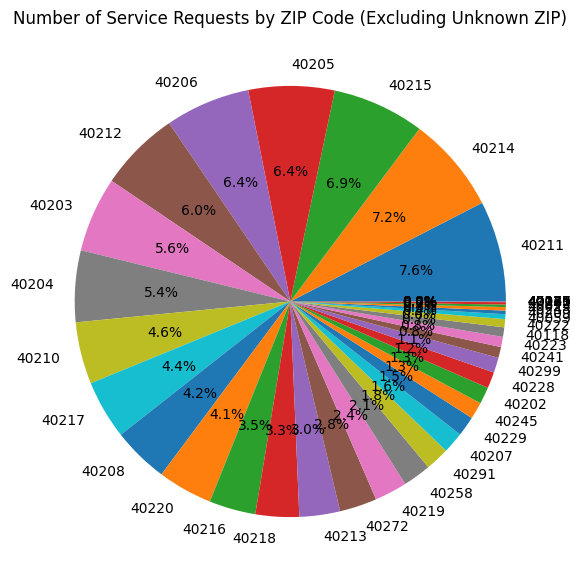

In [18]:
# count requests by ZIP code
tot_sr_zip = lou311_clean.value_counts(subset='zip_code').drop('Unknown')

# set a reasonable plot size
plt.figure(figsize=(7,7))

# plot a pie chart, exclude "Unknown" ZIP
plt.pie(tot_sr_zip, 
        autopct='%1.1f%%',
        labels=tot_sr_zip.index)
plt.title('Number of Service Requests by ZIP Code (Excluding Unknown ZIP)')
plt.show()

In [19]:
lou311_clean['zip_code'].unique()

<StringArray>
[  '40217', 'Unknown',   '40210',   '40206',   '40204',   '40219',   '40216',
   '40205',   '40214',   '40212',   '40207',   '40215',   '40258',   '40228',
   '40211',   '40299',   '40203',   '40213',   '40229',   '40218',   '40023',
   '40220',   '40222',   '40208',   '40291',   '40272',   '40241',   '40245',
   '40223',   '40059',   '40177',   '40242',   '40118',   '40202',   '40243',
   '40209',   '40225',   '40025',   '40041',   '47130',   '40165']
Length: 41, dtype: str

Crowded view with 40 ZIP codes represented, exluding 'Unknown'. Let's trim it down to the top 10 ZIPs by number of requests made.

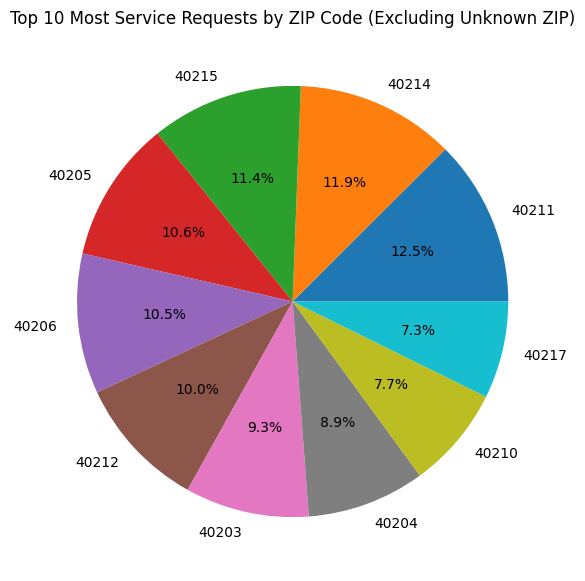

In [20]:

top_sr_zip = tot_sr_zip.nlargest(10)

# set a reasonable plot size
plt.figure(figsize=(7,7))

# plot a pie chart
plt.pie(top_sr_zip, 
        labels=top_sr_zip.index, 
        autopct='%1.1f%%',
        colors=sns.color_palette('tab10'))
plt.title('Top 10 Most Service Requests by ZIP Code (Excluding Unknown ZIP)')
plt.show()


This is kind of pretty, but doesn't inform too terribly much about relative volume of service requests by ZIP code.
A bar chart might be more informative?

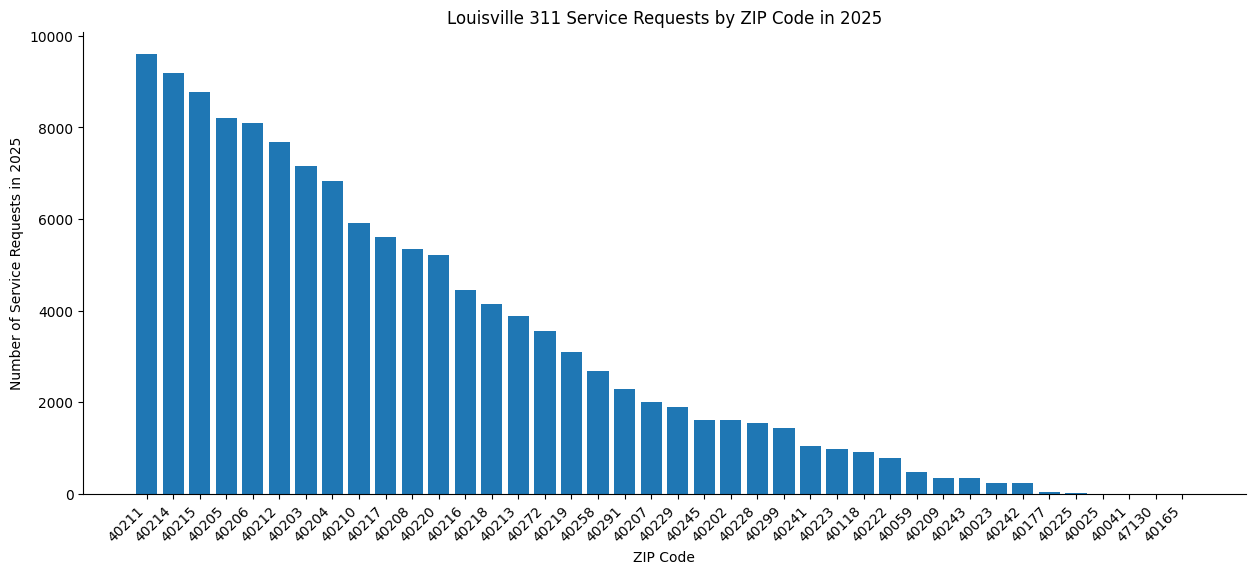

In [21]:
# set a reasonable plot size
plt.figure(figsize=(15,6))

# make it more readable
plt.xlabel("ZIP Code")
plt.ylabel("Number of Service Requests in 2025")
plt.title("Louisville 311 Service Requests by ZIP Code in 2025")
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.bar(tot_sr_zip.index,tot_sr_zip.values)

plt.show()


---
### So what have we gleaned from ZIP code?

Less than I was hoping, it seems. 

I suspect it may be time to step back to look at some other variables in this dataset.

Most of them are strings, which reduces quantitative analysis to various counts, which is perhaps where I should have started anyway. 

So let's begin again by looking at unique values by category.

In [22]:
# print(lou311_clean.info())
print("Number of unique 'service_name': ", lou311_clean['service_name'].nunique())
print("Number of unique 'status_description': ", lou311_clean['status_description'].nunique())
print("Number of unique 'description': ", lou311_clean['description'].nunique())
print("Number of unique 'agency_responsible': ", lou311_clean['agency_responsible'].nunique())
print("Number of unique 'source': ", lou311_clean['source'].nunique())
print("Number of unique 'council_district': ", lou311_clean['council_district'].nunique())


Number of unique 'service_name':  55
Number of unique 'status_description':  2
Number of unique 'description':  103137
Number of unique 'agency_responsible':  35
Number of unique 'source':  2
Number of unique 'council_district':  28


Service name appears to be a reasonably condensed summary of what service is requested per 311 call. 

Which are the most requested services?

<StringArray>
[                    'Animal Issue',                'NSR Miscellaneous',
               'NSR Metro Agencies',                          'Streets',
                      'NSR Utility',                     'Street Signs',
                  'Parking Concern',                            'Trash',
                            'Trees',              'NSR Social Services',
                         'Exterior',                   'NSR Government',
            'Solid Waste Violation',    'Solid Waste Container Request',
                  'Traffic Signals',      'Solid Waste Missed Services',
           'Large Item Appointment',                             'Odor',
                      'Maintenance',               'Drainage and Sewer',
                        'Utilities',                         'Graffiti',
                  'Sidewalks/Curbs',      'Vehicle on Private Property',
                         'Interior',                  'Illegal Dumping',
                   'Smoke Detector', 

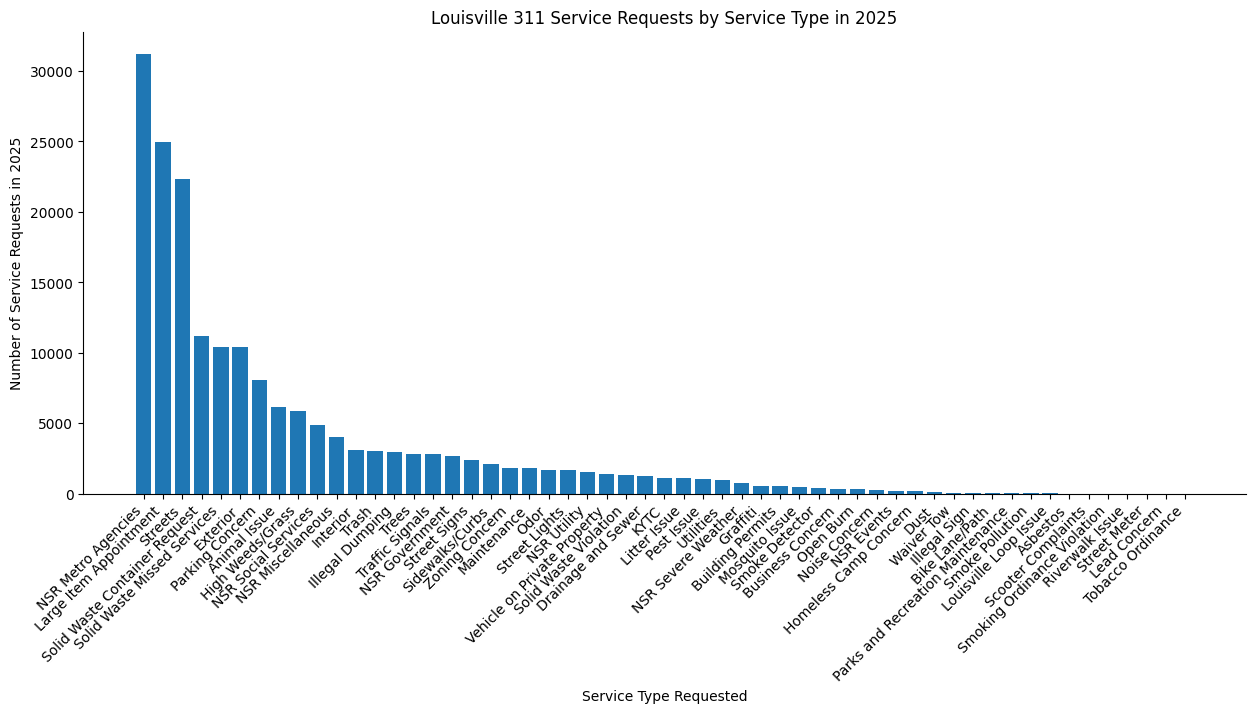

In [23]:
print(lou311_clean['service_name'].unique())

# count requests by service_name
svc_reqs = lou311_clean.value_counts(subset='service_name')

# set a reasonable plot size
plt.figure(figsize=(15,6))

# make it more readable
plt.xlabel("Service Type Requested")
plt.ylabel("Number of Service Requests in 2025")
plt.title("Louisville 311 Service Requests by Service Type in 2025")
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.bar(svc_reqs.index,svc_reqs.values)

plt.show()


From the source at https://data.louisvilleky.gov/datasets/LOJIC::louisville-metro-ky-metro-311-service-request-2025/about

> *Questions are answered and denoted into the reporting system as a Non-Service Request (NSR).*

We are interested in the most requested serivces; or at least, questions aka NSR, should be considered separately. 


In [24]:
# isolate rows where service_name starts with "NSR "
lou311_nsr = lou311_clean.loc[lou311_clean['service_name'].str.startswith('NSR ')]
# now lou311_nsr is a dataframe we can reference if we want to see only info requests, not service requests. which means...

# lou311_sr becomes our dataframe that excludes NSR calls
lou311_sr = lou311_clean.drop(lou311_nsr.index)

Now, for example, we have a clean read on true "service" requests, excluding items the city itself deems "non-service requests," i.e. calls for information only.

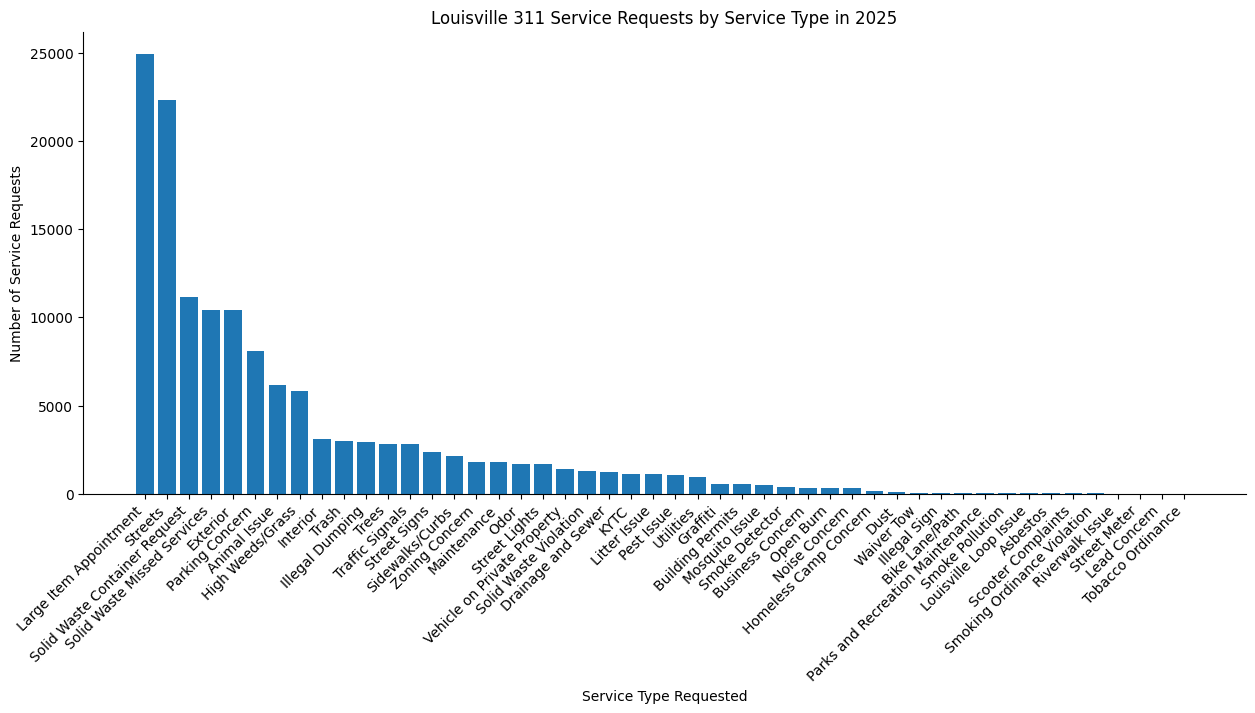

In [25]:
# count requests by service_name
sr_counts = lou311_sr.value_counts(subset='service_name')

# set a reasonable plot size
plt.figure(figsize=(15,6))

# make it more readable
plt.xlabel("Service Type Requested")
plt.ylabel("Number of Service Requests")
plt.title("Louisville 311 Service Requests by Service Type in 2025")
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.bar(sr_counts.index,sr_counts.values)

plt.show()


This is still a bit cumbersome, though. And the further down the list from most to least requested, it becomes essentially impossible to see the bars on the plot. So let's break it up for a closer look.

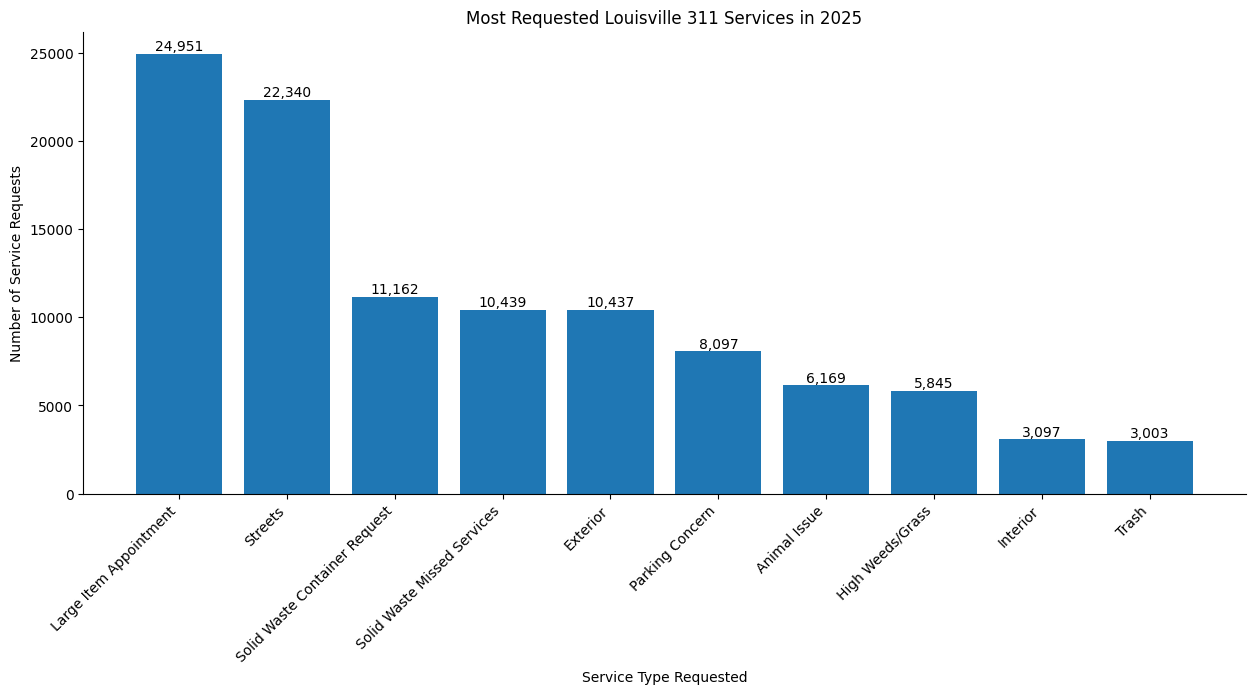

In [26]:
# count requests by service_name
top_sr = sr_counts.nlargest(10)

# set a reasonable plot size
plt.figure(figsize=(15,6))

# make it more readable
plt.xlabel("Service Type Requested")
plt.ylabel("Number of Service Requests")
plt.title("Most Requested Louisville 311 Services in 2025")
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.bar(top_sr.index,top_sr.values)
ax.bar_label(ax.containers[0],label_type='edge', fmt='{:,.0f}')

plt.show()


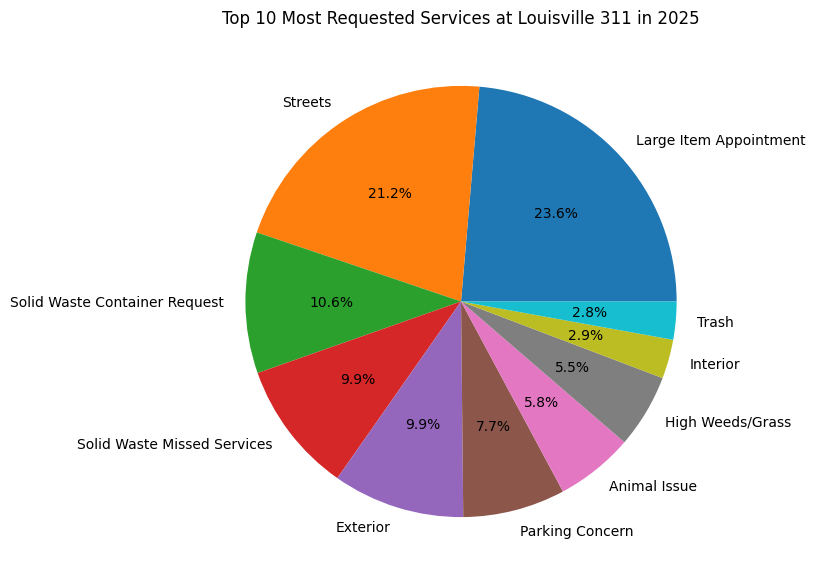

In [27]:
top_sr = top_sr.nlargest(10)

# set a reasonable plot size
plt.figure(figsize=(7,7))

# plot a pie chart
plt.pie(top_sr, 
        labels=top_sr.index, 
        autopct='%1.1f%%')
plt.title('Top 10 Most Requested Services at Louisville 311 in 2025')
plt.show()

The problem with the pie chart, of course, is that it only represents the top ten most requested services. 

Maybe try to lump everything below the top 10, or below the top 20% of overall requests, into a catch-all category?

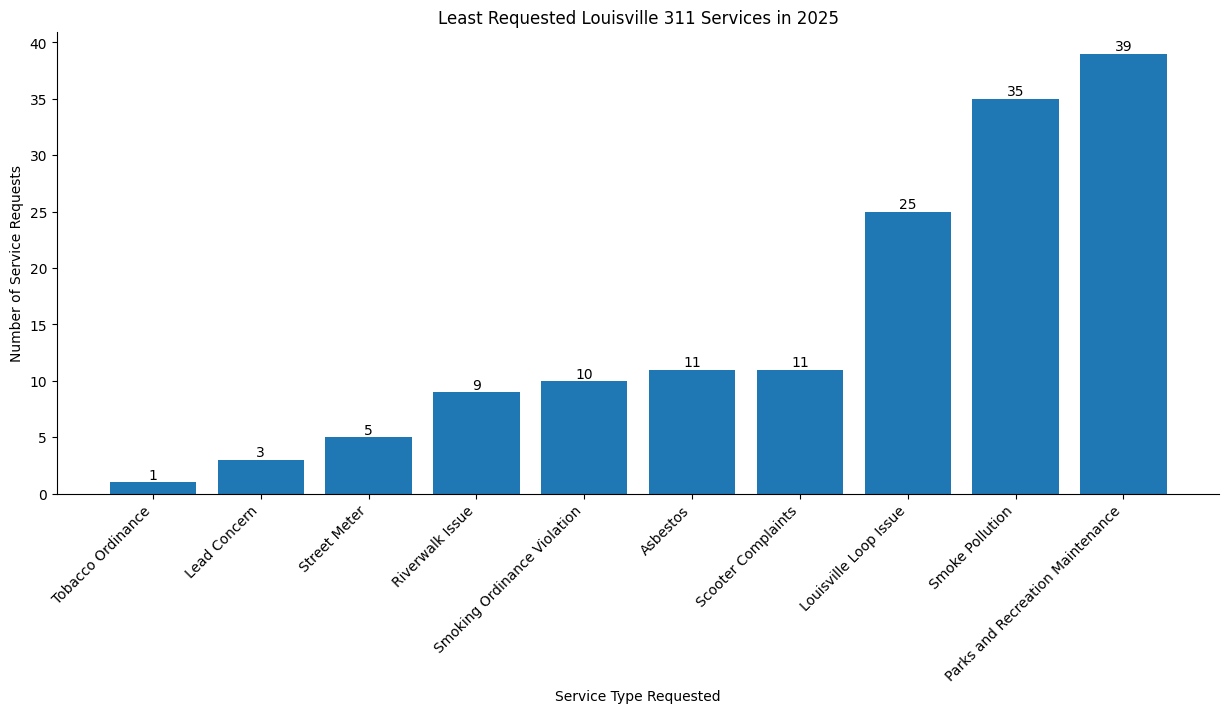

In [28]:
# count requests by service_name
bot_sr = sr_counts.nsmallest(10)

# set a reasonable plot size
plt.figure(figsize=(15,6))

# make it more readable
plt.xlabel("Service Type Requested")
plt.ylabel("Number of Service Requests")
plt.title("Least Requested Louisville 311 Services in 2025")
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.bar(bot_sr.index,bot_sr.values)
ax.bar_label(ax.containers[0],label_type='edge', fmt='{:,.0f}')

plt.show()


---

### Seeking a Complete Pie Chart That is Easy to Read

We want to see the percent contribution of each service request type (service_name) to the annual total.

Looking at no more than ten pie slices, we will break the series into the top 9 and bottom remainder. 

In [29]:
# set aside the top 9 service_name
sr_top9 = sr_counts.nlargest(9)

# create a new series that contains "all the rest" of service_name. 
# rather than count the number of service_name entries below 9, just take nsmallest and exclude the top 9.
# then give it an index value of "Other"
sr_bottom = pd.Series([sr_counts.nsmallest(len(sr_counts)-9).sum()])
sr_bottom.index = ['Other']

# smash together Top 9 & Bottom Else (aka 10th)
sr_top10 = pd.concat([sr_top9, sr_bottom])

sr_top10


Large Item Appointment           24951
Streets                          22340
Solid Waste Container Request    11162
Solid Waste Missed Services      10439
Exterior                         10437
Parking Concern                   8097
Animal Issue                      6169
High Weeds/Grass                  5845
Interior                          3097
Other                            34725
dtype: int64

### And so...

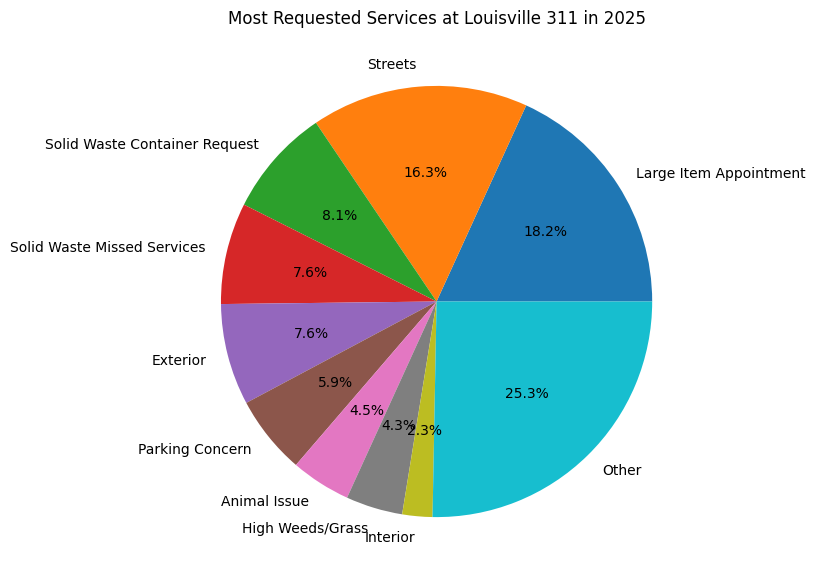

In [30]:
# set a reasonable plot size
plt.figure(figsize=(7,7))

# plot a pie chart
plt.pie(sr_top10, 
        labels=sr_top10.index, 
        autopct='%1.1f%%')
plt.title('Most Requested Services at Louisville 311 in 2025')
plt.show()

Just at a glance, we can see roughly half of all service requests are of just four types: 
- Large Item Appointment
- Streets
- Solid Waste Container Request
- Solid Waste Missed Services

Concern: This, like the ZIP code breakdown, still does not bring to mind any questions motivating a larger or deeper investigation.

---

OK, stuck a bit here. 

The objective is to plot a bar chart with months along the x-axis and value_counts of service_name on the y-axis, but to make the bar plot stacked: each month would show a multi-color column, and the colors would align to a specific service_name.

In [31]:
# lou311_sr['service_name'].value_counts()
# not needed ... we already have this in sr_counts

top25mark = sr_counts.quantile(0.75)
print("The top 25% of service requests by count are greater than", top25mark)

top_list = sr_counts.index[sr_counts > top25mark].tolist()
bot_list = sr_counts.index[sr_counts < top25mark].tolist()
# below is the heinous garbage we tried BEFORE coming around to .tolist() ... yeesh.

# top_list = []
# bot_list = []
# for i in sr_counts:
#     if sr_counts[i] > top25mark:
#         top_list = top_list + sr_counts
#     else:
#         bot_list = bot_list + sr_counts


The top 25% of service requests by count are greater than 2829.0


Text(0, 0.5, 'Number of Requests')

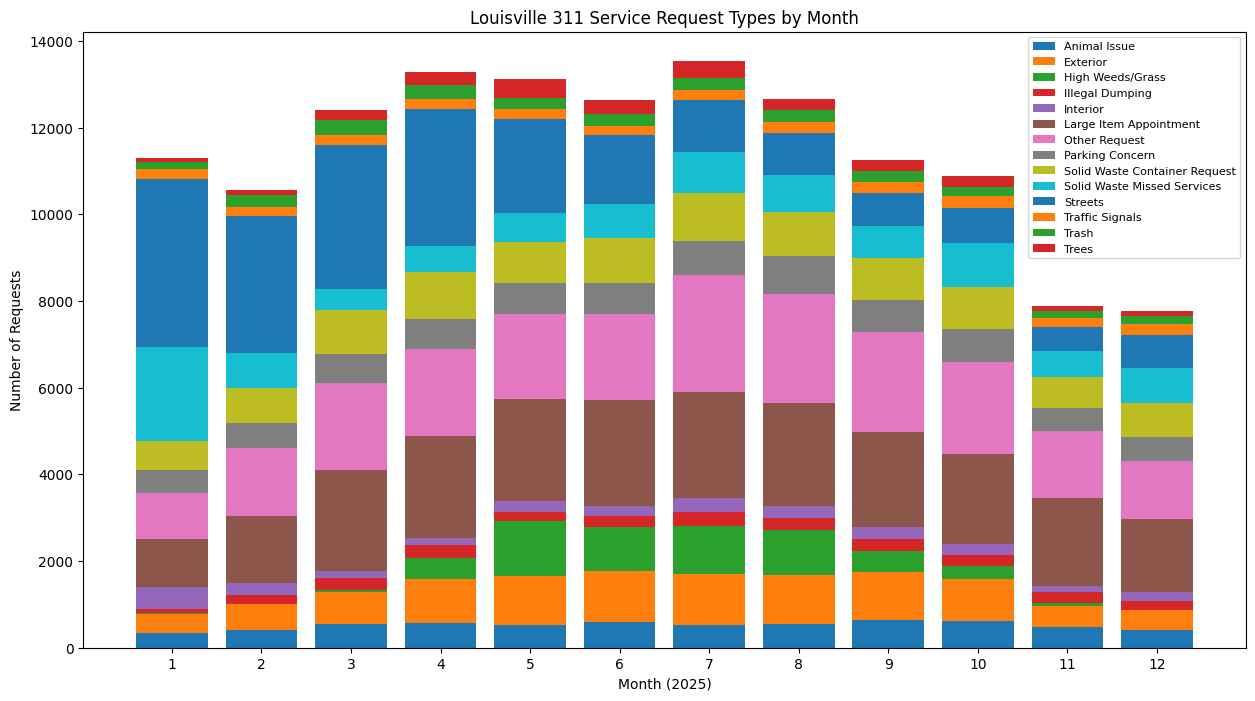

In [32]:
# add request month column from requested_datetime
lou311_sr['req_month'] = lou311_sr['requested_datetime'].dt.month

# change bottom quartile service_name to "Other Request", but keep previous complete DataFrame
lou311_trimSR = lou311_sr.replace(to_replace=bot_list, value='Other Request')

# # trying to create a new DataFrame with req_month as index, service_name as columns, and service_name.value_counts() as values / data
# sr_byMonth = pd.DataFrame(axes=lou311_trimSR['req_month'].groupby(lou311_trimSR.req_month), columns=lou311_trimSR['service_name'], data=lou311_trimSR['service_name'].value_counts())

good_group = lou311_trimSR.groupby('req_month')['service_name'].value_counts()

# "unstack" that good_group series to get the DataFrame needed
sr_byMonth = good_group.unstack()

# loop the actual plotting to get the service request types (service_name) to accumulate (stack)
sum_count=0
fig = plt.figure(figsize=(15,8))
for col in sr_byMonth.columns:
    plt.bar(sr_byMonth.index, sr_byMonth[col], bottom=sum_count, label=col)
    sum_count = sum_count+sr_byMonth[col]

plt.xticks(sr_byMonth.index) # show all month labels
plt.legend(fontsize=8, loc='upper right') # small font for legend, move to upper right section
plt.title("Louisville 311 Service Request Types by Month")
plt.xlabel('Month (2025)')
plt.ylabel('Number of Requests')

Text(0, 0.5, 'Number of Requests')

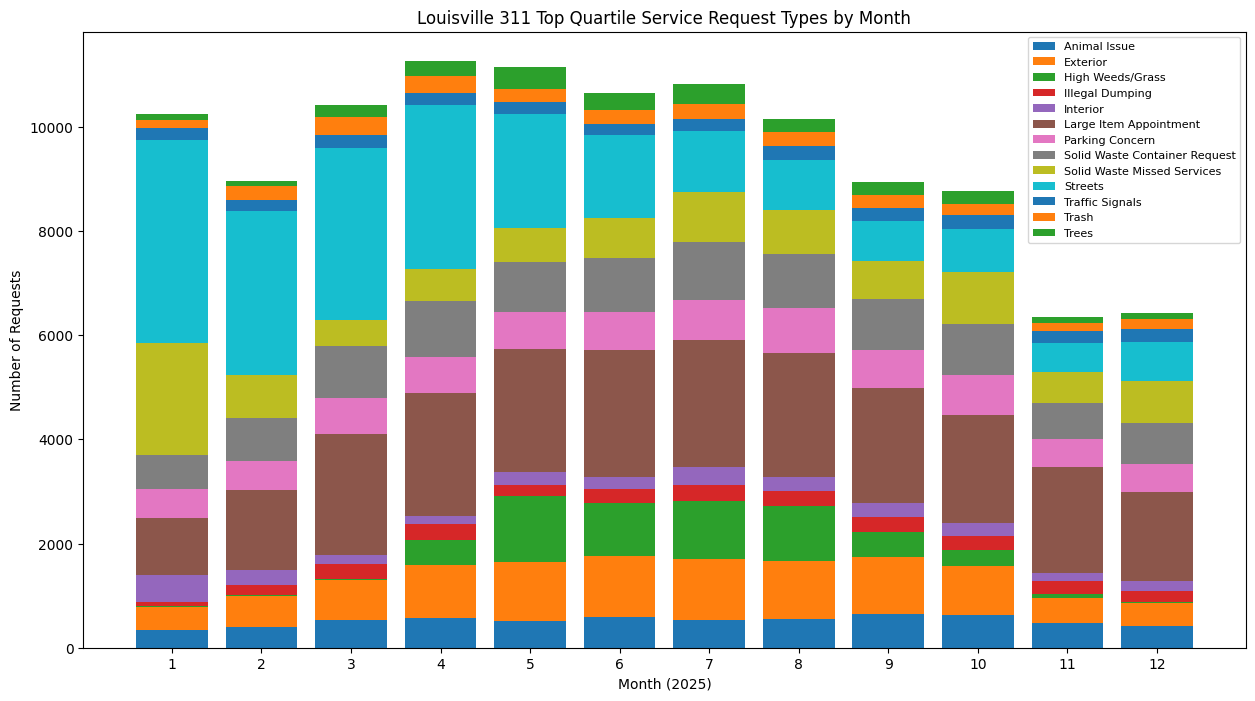

In [33]:
# now just the top quartile service request types
sr_byMo_topQ = sr_byMonth.drop('Other Request', axis=1)

# loop the actual plotting to get the service request types (service_name) to accumulate (stack)
sum_count=0
fig = plt.figure(figsize=(15,8))
for col in sr_byMo_topQ.columns:
    plt.bar(sr_byMo_topQ.index, sr_byMo_topQ[col], bottom=sum_count, label=col)
    sum_count = sum_count+sr_byMo_topQ[col]

plt.xticks(sr_byMo_topQ.index) # show all month labels
plt.legend(fontsize=8, loc='upper right') # small font for legend, move to upper right section
plt.title("Louisville 311 Top Quartile Service Request Types by Month")
plt.xlabel('Month (2025)')
plt.ylabel('Number of Requests')
